 # ** Task 1 **

In [12]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot  as plt

In [13]:
train_data= torchvision.datasets.MNIST(
    root="./folder",
    train=True,
    download= True,
    transform= transforms.ToTensor(),
)

test_data= torchvision.datasets.MNIST(
    root="./folder",
    train=False,
    download= True,
    transform= transforms.ToTensor(),
)

More about this dataset-

In [14]:
print("Number of images in training datset- ",len(train_data))
print("Number of images in test datset- ",len(test_data))

image, labels = train_data[0]

print("Image Shape =",image.shape)
print("Expected Label / Number= ", labels)
print("Type of image = ", image.dtype)

i= [train_data[j][1] for j in range(len(train_data))]
unique, counts= np.unique(i,return_counts=True)
for digit,count in zip(unique,counts):
    print(f"Digit {int(digit)} : {int(count)}")



Number of images in training datset-  60000
Number of images in test datset-  10000
Image Shape = torch.Size([1, 28, 28])
Expected Label / Number=  5
Type of image =  torch.float32
Digit 0 : 5923
Digit 1 : 6742
Digit 2 : 5958
Digit 3 : 6131
Digit 4 : 5842
Digit 5 : 5421
Digit 6 : 5918
Digit 7 : 6265
Digit 8 : 5851
Digit 9 : 5949


Visualizing the images-

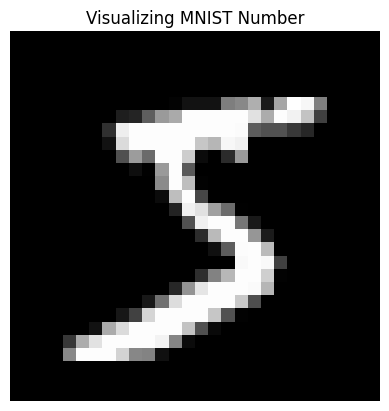

In [15]:
plt.imshow(image.squeeze(),cmap="grey")
plt.title("Visualizing MNIST Number")
plt.axis("off")
plt.show()

Now visualizing 5 images --

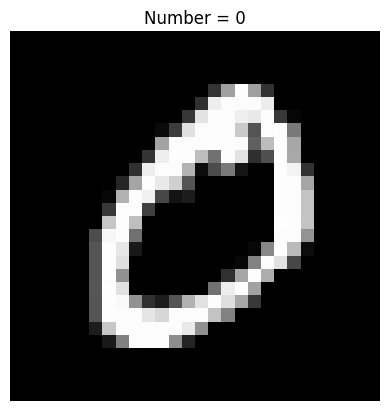

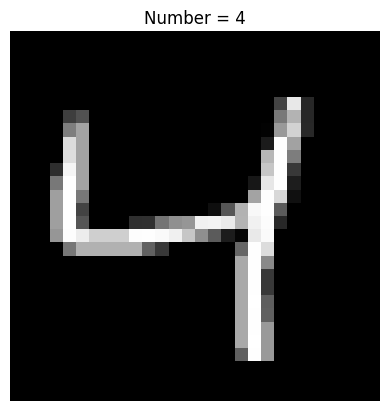

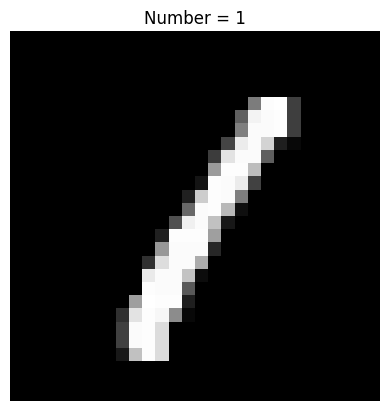

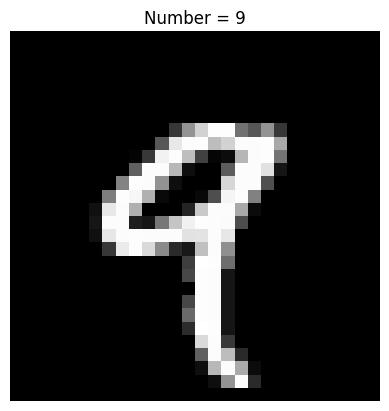

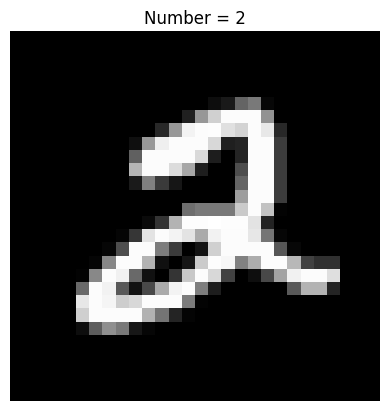

In [16]:
for i in range(1,6):
    image,label= train_data[i]
    plt.imshow(image.squeeze(),cmap="grey")
    plt.title(f"Number = {label}")
    plt.axis("off")
    plt.show()
    

Normalizing the datsets

In [17]:
pixel= train_data.data.float()/255

mean=pixel.mean()
std= pixel.std()

print(mean)
print(std)

transformation= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])

train_data= torchvision.datasets.MNIST(
    root="./folder",
    train=True,
    download= True,
    transform= transformation,
)

test_data= torchvision.datasets.MNIST(
    root="./folder",
    train=False,
    download= True,
    transform= transformation,
)



tensor(0.1307)
tensor(0.3081)


# ** Task 2 **

Transforming the dataset by applying Augmentation the train dataset---- 
Note- Only augmentation on test dataset

In [18]:
augmentation_transform= transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomCrop(28,padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean,std),
    
])

train_data= torchvision.datasets.MNIST(
    root="./folder",
    train=True,
    download= True,
    transform= augmentation_transform,
)


Creating a Dataloader for test and train data with batchsize=64

In [19]:
train_loader=torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader=torch.utils.data.DataLoader(
    test_data,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

Details about the batch etc with train,test loader

In [20]:
images, labels = next(iter(train_loader))

print(f"Batch Image shape = {images.shape}")
print(f"Batch Label shape = {labels.shape}")
print(f"Training batch length = {len(train_loader)}")
print(f"Testing batch length = {len(test_loader)}")




c:\Users\Anushree\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch Image shape = torch.Size([64, 1, 28, 28])
Batch Label shape = torch.Size([64])
Training batch length = 938
Testing batch length = 157


# Task 3 

In [21]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.features=nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier= nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,10)

        )
    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)

        return x
    

In [25]:
model=MNISTModel()
print(model)

images, labels = next(iter(train_loader))



testoutput=model(images)
print(testoutput.shape)

MNISTModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


c:\Users\Anushree\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([64, 10])


# Task 4

In [26]:
criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr=0.001)




num_epoch=7

for epoch in range(num_epoch):
    model.train()
    running_loss=0
    for images,labels in train_loader:
        optimizer.zero_grad()
        output= model(images)
        loss= criterion(output,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    print(f"Loss ={running_loss/len(train_loader)} ")




c:\Users\Anushree\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Loss =0.49476300918661964 
Loss =0.23860816447449518 
Loss =0.19889561483648413 
Loss =0.1703532281329732 
Loss =0.1531773119239506 
Loss =0.1405034128979627 
Loss =0.1280896928844485 


# Task 5

In [28]:
cor=0
tot =0
totloss=0

model.eval()
with torch.no_grad():
    for images,labels in test_loader:
        output=model(images)
        _,predict= torch.max(output,1)
        loss=criterion(output,labels)
        totloss+=loss.item()
        tot+=labels.size(0)
        cor+= (predict==labels).sum().item()

avgloss= totloss/len(test_loader)
accuracy= (cor/tot)*100

print(f"Total loss = {avgloss}")

print(f"Accuracy = {accuracy}")





Total loss = 0.03485143693617417
Accuracy = 98.75


# Task 6

In [30]:
torch.save(model.state_dict(),"mnsitmod.pth")


images,labels = next(iter(test_loader))

img= images[0].unsqueeze(0)
output= model(img)

_,prediction = torch.max(output,1)

print("Predicited = ",prediction.item())
print("Actual number = ", labels[0].item())

c:\Users\Anushree\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicited =  9
Actual number =  9


Visualizing this- 

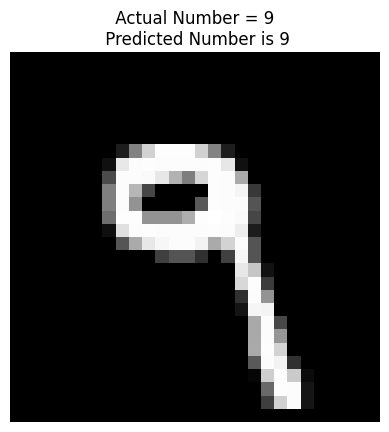

In [32]:
plt.imshow(
    img.squeeze(),cmap="gray"
)

plt.title(f" Actual Number = {labels[0].item()} \n Predicted Number is {prediction.item()}")

plt.axis("off")

plt.show()

**Quick test**

I wrote a random digit on MS Paint , and i wanted to see whether my model would be able to predict it properly.

Prediction 5


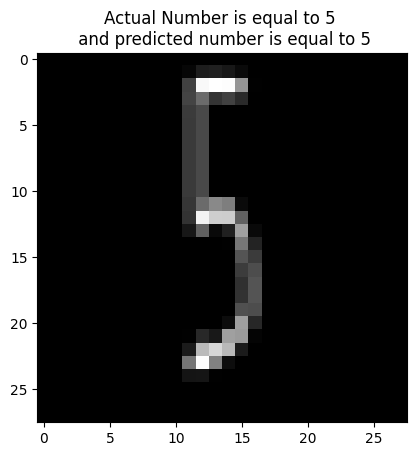

In [42]:
from PIL import Image
import torchvision.transforms as transforms

img= Image.open("digit.png").convert("L")

transform= transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x:1-x),
    transforms.Normalize((mean),(std))
])

x= transform(img)
x = x.unsqueeze(0)

model.eval()

with torch.no_grad():
    output= model(x)
    pred= output.argmax(dim=1)

print("Prediction",pred.item())

plt.imshow(x.squeeze(),cmap="gray")
plt.title(f"Actual Number is equal to 5 \n and predicted number is equal to {pred.item()}")
plt.show()

**I have also made an application based on my model, which lets you draw the number using tkiner and predicts the number given using my model. It is under the application.py**